<a href="https://colab.research.google.com/github/sionide/CMPE-131-HW3/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn import metrics

In [18]:
# idk why I have to do this but it works
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/separable2vs8.csv', index_col=0)
df.info()

Saving separable2vs8.csv to separable2vs8 (2).csv
<class 'pandas.core.frame.DataFrame'>
Index: 985 entries, 1 to 1
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      985 non-null    float64
 1   x2      985 non-null    float64
 2   y       985 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 30.8 KB


<Axes: xlabel='x1', ylabel='x2'>

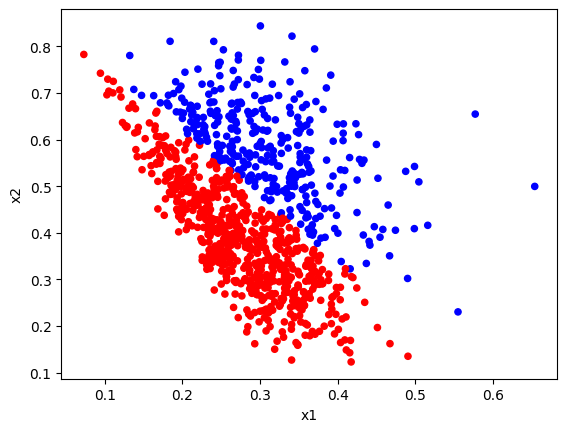

In [4]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)

In [5]:
df.head()

,x1,x2,y
x0,,,
1,0.458248,0.407339,-1
1,0.308186,0.236474,1
1,0.170111,0.590144,1
1,0.239096,0.424140,1
1,0.305740,0.475571,-1


In [6]:
X = np.array(df[['x1', 'x2']])
y = np.array(df[['y']])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=60, random_state=45
)

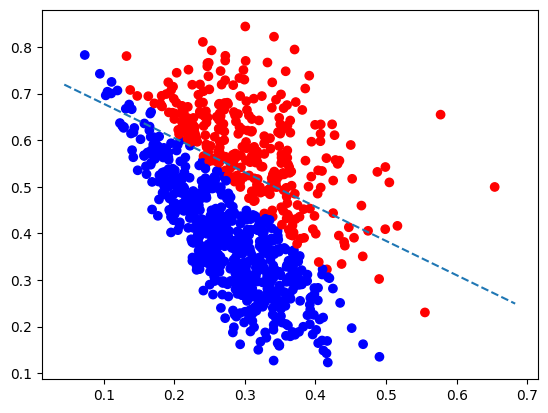

In [17]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train,y_train.ravel())
colors=[]
for y_col in y_train:
  if y_col == 1:
      colors.append('b')
  else:
      colors.append('r')

plt.scatter(X_train[:,0], X_train[:,1], color=colors)

intercept = -lr.intercept_[0]/lr.coef_[0,1]
slope = -lr.coef_[0,0]/lr.coef_[0,1]

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )

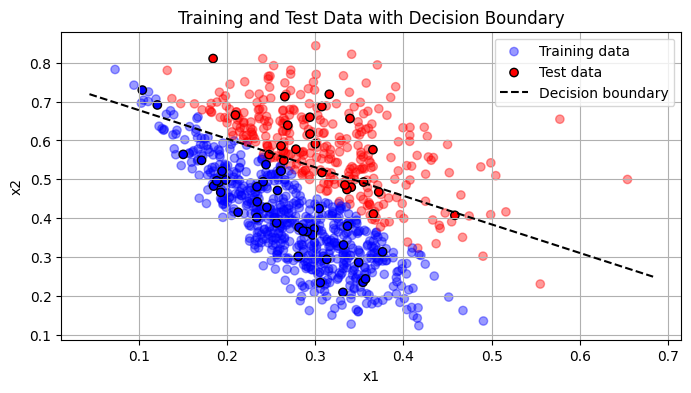

In [16]:
plt.figure(figsize=(8, 4))
# Training data
plt.scatter(
  X_train[:, 0],
  X_train[:, 1],
  color=colors,
  alpha=0.4,
  label="Training data"
)
# Test data
test_colors = np.where(y_test.ravel() == 1, "b", "r")
plt.scatter(
  X_test[:, 0],
  X_test[:, 1],
  color=test_colors,
  edgecolors="black",
  label="Test data"
)
# Decision boundary
intercept = -lr.intercept_[0] / lr.coef_[0, 1]
slope = -lr.coef_[0, 0] / lr.coef_[0, 1]
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(
  x_vals,
  y_vals,
  "--",
  color="black",
  label="Decision boundary"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training and Test Data with Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()


## Part B

When the random state is 45:

Accuracy score = 0.905

Precision score = 0.795

F1 score = 0.864


When random state is 42:

Accuracy score = 0.915

Precision score = 0.884

F1 score = 0.935

Changing the max iter did not result in a different outcome, however, changing the random state changed the outcome.

In [ ]:
y_pred_train = lr.predict(X_train)

# what is a confusion matrix? 2 dimensions
metrics.confusion_matrix(y_train, y_pred_train)

array([[247,  66],
       [ 88, 524]])

In [ ]:
# accuracy score = (True positive + true negative) / total predictions
metrics.accuracy_score(y_train, y_pred_train)

0.9048648648648648

In [ ]:
y_pred = lr.predict(X_test)

metrics.confusion_matrix(y_test, y_pred)

"""
array:

this may be wrong? but this is the idea
True negative | False negative
False postive | True positive
"""

array([[14,  9],
       [ 2, 35]])

In [ ]:
metrics.accuracy_score(y_test, y_pred)

0.8166666666666667

In [ ]:
# Precision score = true positive / (true positive + false positive)
metrics.precision_score(y_test, y_pred)

# WHAT IS THIS??
metrics.recall_score(y_test, y_pred)

0.7954545454545454

In [ ]:
# HARMONIC MEAN OR SMTH IDK
# 1/3 + 1/5 =???
# FLIP BOTH
# 3/1 + 5/1 = 8/2 = 4
metrics.f1_score(y_test, y_pred)

0.8641975308641975

## Part C
Confusion Matrix: labels how many were true/false negatives/postives

Accuracy: measures how many were correctly classified

Precision: how many positives were correct

Recall: How many true positives were identified

F1 : how well the performance was overall by using Recall and Precision

F1 is the most useful metric because it balances Recall and precision


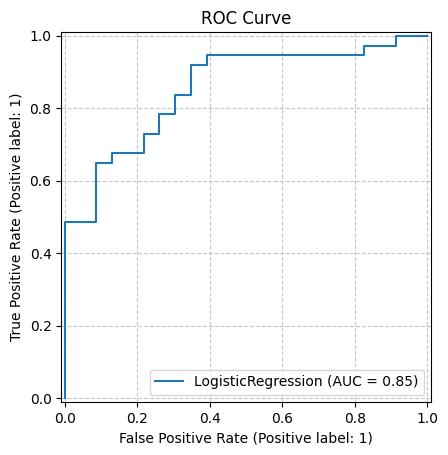

In [ ]:
# WHAT IS AN ROC CURVE?
fig_roc, ax_roc = plt.subplots(1, 1)
metrics.RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax_roc)
plt.title('ROC Curve')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()